# Trading Data Analysis

## Overview
Comprehensive analysis of the stock dataset containing 50+ stocks with OHLCV data from 2025.

**Dataset Structure**
- 50+ stock CSV files in `/A_Data_Gathering/dataset/stocks/`
- Columns: Date, Adj Close, Close, High, Low, Open, Volume
- Date range: January 2025 to April 2026 (323 trading days)

**Analysis Phases**
1. Exploratory Data Analysis (EDA)
2. Technical Analysis
3. Market Analysis
4. Advanced Pattern Recognition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DATASET_PATH = "/scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/A_Data_Gathering/dataset/stocks"
OUTPUT_PATH = "/scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis"

print("Libraries loaded.")

Libraries loaded.


---
## Phase 1: Exploratory Data Analysis (EDA)
### 1.1 Dataset Overview — Load & Inspect

In [2]:
def load_stock_data():
    stock_data = {}
    for file in sorted(os.listdir(DATASET_PATH)):
        if file.endswith('.csv'):
            symbol = file.split('.')[0]
            try:
                df = pd.read_csv(os.path.join(DATASET_PATH, file))
                df = df.iloc[1:].copy()  # drop duplicate header row
                df['Date'] = pd.to_datetime(df['Date'])
                for col in ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
                df.set_index('Date', inplace=True)
                df.sort_index(inplace=True)
                stock_data[symbol] = df
            except Exception as e:
                print(f"Error loading {symbol}: {e}")
    return stock_data

stock_data = load_stock_data()
print(f"Loaded {len(stock_data)} stocks")
print(f"Symbols: {sorted(stock_data.keys())}")

# Dataset overview
sample = next(iter(stock_data.values()))
print(f"\nDate range: {sample.index.min().date()} → {sample.index.max().date()}")
print(f"Trading days: {len(sample)}")
print(f"\nColumns: {list(sample.columns)}")
print(f"\nSample data ({list(stock_data.keys())[0]}):")
display(sample.head())

Loaded 60 stocks
Symbols: ['AGCO', 'ALLE', 'ALNY', 'AVB', 'BR', 'BURL', 'BWXT', 'CALM', 'CBOE', 'CMI', 'DGX', 'DOV', 'EWBC', 'EXR', 'FAF', 'FVRR', 'GGG', 'HIW', 'HOPE', 'HXL', 'IAC', 'IT', 'ITW', 'JBHT', 'KLAC', 'KMT', 'LAZ', 'LOGI', 'LPLA', 'MAA', 'MCK', 'MCO', 'MLI', 'MSI', 'MTB', 'NOC', 'NSA', 'NTES', 'PAYC', 'PNW', 'PWR', 'REG', 'REGN', 'ROK', 'ROP', 'RPM', 'SBAC', 'SF', 'SLG', 'SMG', 'SSB', 'TRIN', 'TXRH', 'UBSI', 'VMC', 'VRSN', 'WAB', 'WAL', 'WERN', 'YELP']

Date range: 2025-01-02 → 2026-04-17
Trading days: 323

Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Sample data (AGCO):


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-01-02,90.104294,91.309998,94.870003,91.129997,94.169998,468900
2025-01-03,91.081223,92.300003,92.709999,90.870003,91.580002,575600
2025-01-06,89.946404,91.150002,94.169998,91.000000,93.449997,1031400
2025-01-07,90.420059,91.629997,92.449997,90.709999,91.330002,738600
2025-01-08,89.038551,90.230003,90.570000,89.209999,90.550003,692600


### 1.2 Data Quality Check

In [3]:
quality_rows = []
issues = []

for symbol, df in stock_data.items():
    missing = df.isnull().sum().sum()
    dups = df.index.duplicated().sum()
    quality_rows.append({
        'Symbol': symbol,
        'Days': len(df),
        'Start': df.index.min().date(),
        'End': df.index.max().date(),
        'Missing Values': missing,
        'Duplicate Dates': dups
    })
    if missing > 0 or dups > 0:
        issues.append(f"{symbol}: {missing} missing, {dups} duplicates")

quality_df = pd.DataFrame(quality_rows).set_index('Symbol')
print(f"=== Data Quality Summary ===")
print(f"Total stocks: {len(quality_df)}")
print(f"Stocks with issues: {len(issues)}")
if issues:
    for i in issues:
        print(f"  ⚠ {i}")
else:
    print("  ✓ All stocks clean — no missing values or duplicate dates")
display(quality_df.describe())

=== Data Quality Summary ===
Total stocks: 60
Stocks with issues: 0
  ✓ All stocks clean — no missing values or duplicate dates


,Days,Missing Values,Duplicate Dates
count,60.0,60.0,60.0
mean,323.0,0.0,0.0
std,0.0,0.0,0.0
min,323.0,0.0,0.0
25%,323.0,0.0,0.0
50%,323.0,0.0,0.0
75%,323.0,0.0,0.0
max,323.0,0.0,0.0


### 1.3 Basic Statistics — Daily Returns & Performance Metrics

In [4]:
for symbol, df in stock_data.items():
    df['Daily_Return'] = df['Close'].pct_change()
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

perf_rows = []
for symbol, df in stock_data.items():
    ann_return = df['Daily_Return'].mean() * 252
    ann_vol = df['Daily_Return'].std() * np.sqrt(252)
    total_return = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    perf_rows.append({
        'Symbol': symbol,
        'Total_Return_%': round(total_return, 2),
        'Ann_Return': round(ann_return, 4),
        'Ann_Volatility': round(ann_vol, 4),
        'Sharpe': round(sharpe, 3),
        'Skewness': round(df['Daily_Return'].skew(), 3),
        'Kurtosis': round(df['Daily_Return'].kurt(), 3),
    })

performance_df = pd.DataFrame(perf_rows).set_index('Symbol').sort_values('Total_Return_%', ascending=False)

# --- Selection variables used by all downstream cells ---
N_SHOWCASE = 5          # stocks shown in price/MACD charts (top N + bottom N)
N_VOL_PLOT = 6          # stocks shown in volume / S/R plots
N_BREAKOUT_PLOT = 3     # stocks shown in breakout visual

top_n    = performance_df.head(N_SHOWCASE).index.tolist()
bottom_n = performance_df.tail(N_SHOWCASE).index.tolist()
selected = top_n + bottom_n                                 # top5 + bottom5
top_vol  = performance_df.head(N_VOL_PLOT).index.tolist()  # top6 for vol/S&R
top_bo   = performance_df.head(N_BREAKOUT_PLOT).index.tolist()

n_display = min(10, len(performance_df) // 2)
print("=== Top Performers ===")
display(performance_df.head(n_display))
print("\n=== Bottom Performers ===")
display(performance_df.tail(n_display))
print("\n=== Cross-Stock Statistics ===")
display(performance_df.describe())

=== Top Performers ===


,Total_Return_%,Ann_Return,Ann_Volatility,Sharpe,Skewness,Kurtosis
Symbol,,,,,,
KLAC,181.40,0.9225,0.4727,1.951,-0.070,5.563
BWXT,111.50,0.6878,0.4513,1.524,0.406,7.308
PWR,90.77,0.5858,0.3962,1.478,-1.059,10.221
CMI,80.41,0.5183,0.3356,1.544,0.049,5.268
KMT,64.21,0.4673,0.3953,1.182,-0.566,12.842
MLI,53.18,0.3788,0.2993,1.266,-0.409,6.906
MCK,53.01,0.3691,0.2722,1.356,2.440,26.137
CBOE,52.69,0.3563,0.2233,1.596,-0.367,0.588
ROK,48.00,0.3606,0.3305,1.091,1.221,9.181



=== Bottom Performers ===


,Total_Return_%,Ann_Return,Ann_Volatility,Sharpe,Skewness,Kurtosis
Symbol,,,,,,
AVB,-19.89,-0.1493,0.2199,-0.679,-0.371,4.363
HIW,-23.16,-0.1678,0.2758,-0.608,-0.736,4.219
CALM,-27.48,-0.1769,0.3858,-0.458,-0.062,6.822
BR,-28.18,-0.2278,0.2491,-0.914,-0.389,4.566
YELP,-28.49,-0.1957,0.3648,-0.536,-0.063,5.635
ROP,-29.46,-0.2426,0.2450,-0.990,-1.019,7.094
SLG,-36.71,-0.2843,0.3830,-0.742,-0.103,0.886
PAYC,-36.98,-0.2918,0.3725,-0.783,0.103,4.727
FVRR,-65.95,-0.7321,0.4663,-1.570,-0.352,1.267



=== Cross-Stock Statistics ===


,Total_Return_%,Ann_Return,Ann_Volatility,Sharpe,Skewness,Kurtosis
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,15.617500,0.121505,0.320835,0.385817,0.026533,7.919567
std,39.957675,0.282264,0.077734,0.764874,1.180764,10.193695
min,-68.010000,-0.773900,0.168400,-1.672000,-3.621000,0.328000
25%,-3.877500,0.012575,0.261525,0.040750,-0.448000,3.641000
50%,12.155000,0.128350,0.307300,0.474500,-0.147000,5.448000
75%,32.817500,0.282225,0.386225,0.917500,0.252000,7.612000
max,181.400000,0.922500,0.472700,1.951000,5.729000,71.449000


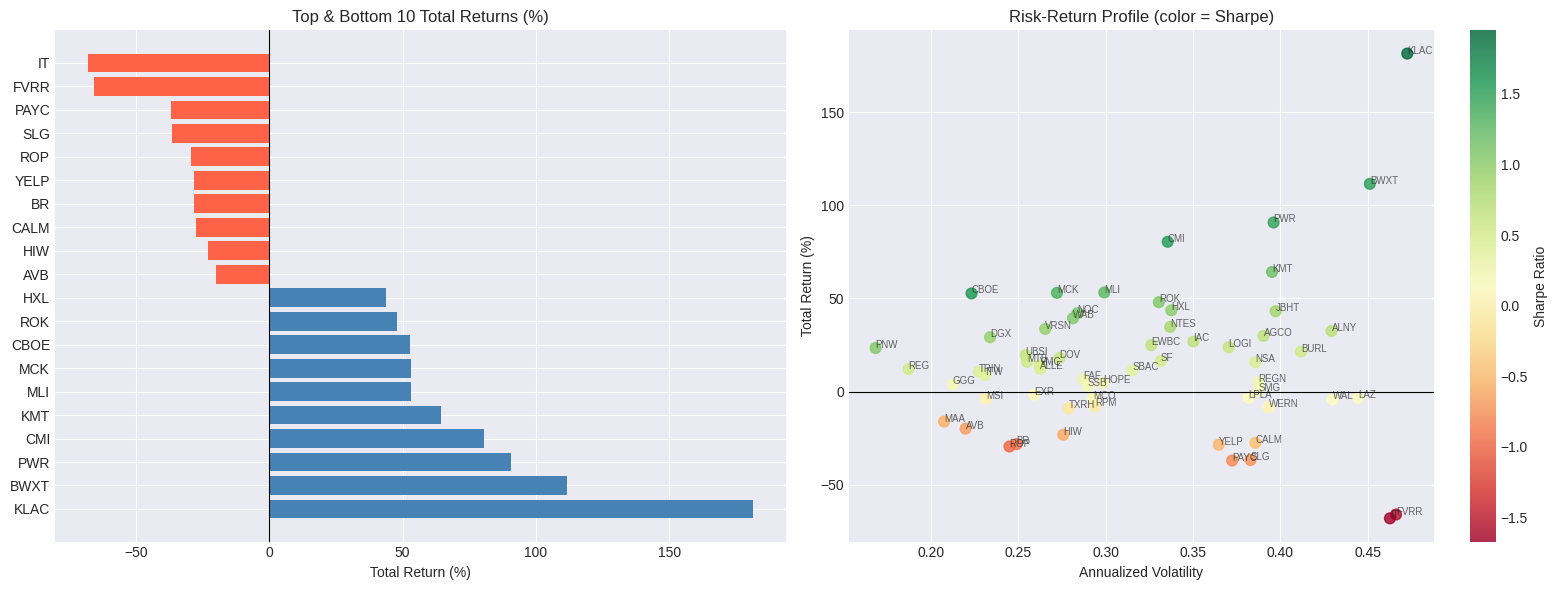

In [5]:
# Performance visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — top & bottom performers
n = 10
top = performance_df.head(n)
bottom = performance_df.tail(n)
combined = pd.concat([top, bottom])
colors = ['steelblue' if r > 0 else 'tomato' for r in combined['Total_Return_%']]
axes[0].barh(combined.index, combined['Total_Return_%'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Top & Bottom 10 Total Returns (%)')
axes[0].set_xlabel('Total Return (%)')

# Risk-return scatter
sc = axes[1].scatter(
    performance_df['Ann_Volatility'], performance_df['Total_Return_%'],
    c=performance_df['Sharpe'], cmap='RdYlGn', s=60, alpha=0.8
)
plt.colorbar(sc, ax=axes[1], label='Sharpe Ratio')
for sym, row in performance_df.iterrows():
    axes[1].annotate(sym, (row['Ann_Volatility'], row['Total_Return_%']), fontsize=7, alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Annualized Volatility')
axes[1].set_ylabel('Total Return (%)')
axes[1].set_title('Risk-Return Profile (color = Sharpe)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'performance_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Volume Pattern Analysis

=== Volume Spike Summary (top 15 by spike days) ===


,Spike_Days,Spike_%,Avg_Spike_Vol,Avg_Normal_Vol,Spike_Ratio
Symbol,,,,,
LOGI,43,13.3,1602670,681094,2.35
LPLA,38,11.8,1799429,723500,2.49
MCK,37,11.5,1529832,719589,2.13
WAL,37,11.5,2453259,1013823,2.42
FAF,36,11.1,1698347,763439,2.22
BWXT,36,11.1,2133333,998310,2.14
IT,36,11.1,2189200,961861,2.28
LAZ,35,10.8,2027143,974953,2.08
VMC,35,10.8,2000923,937682,2.13


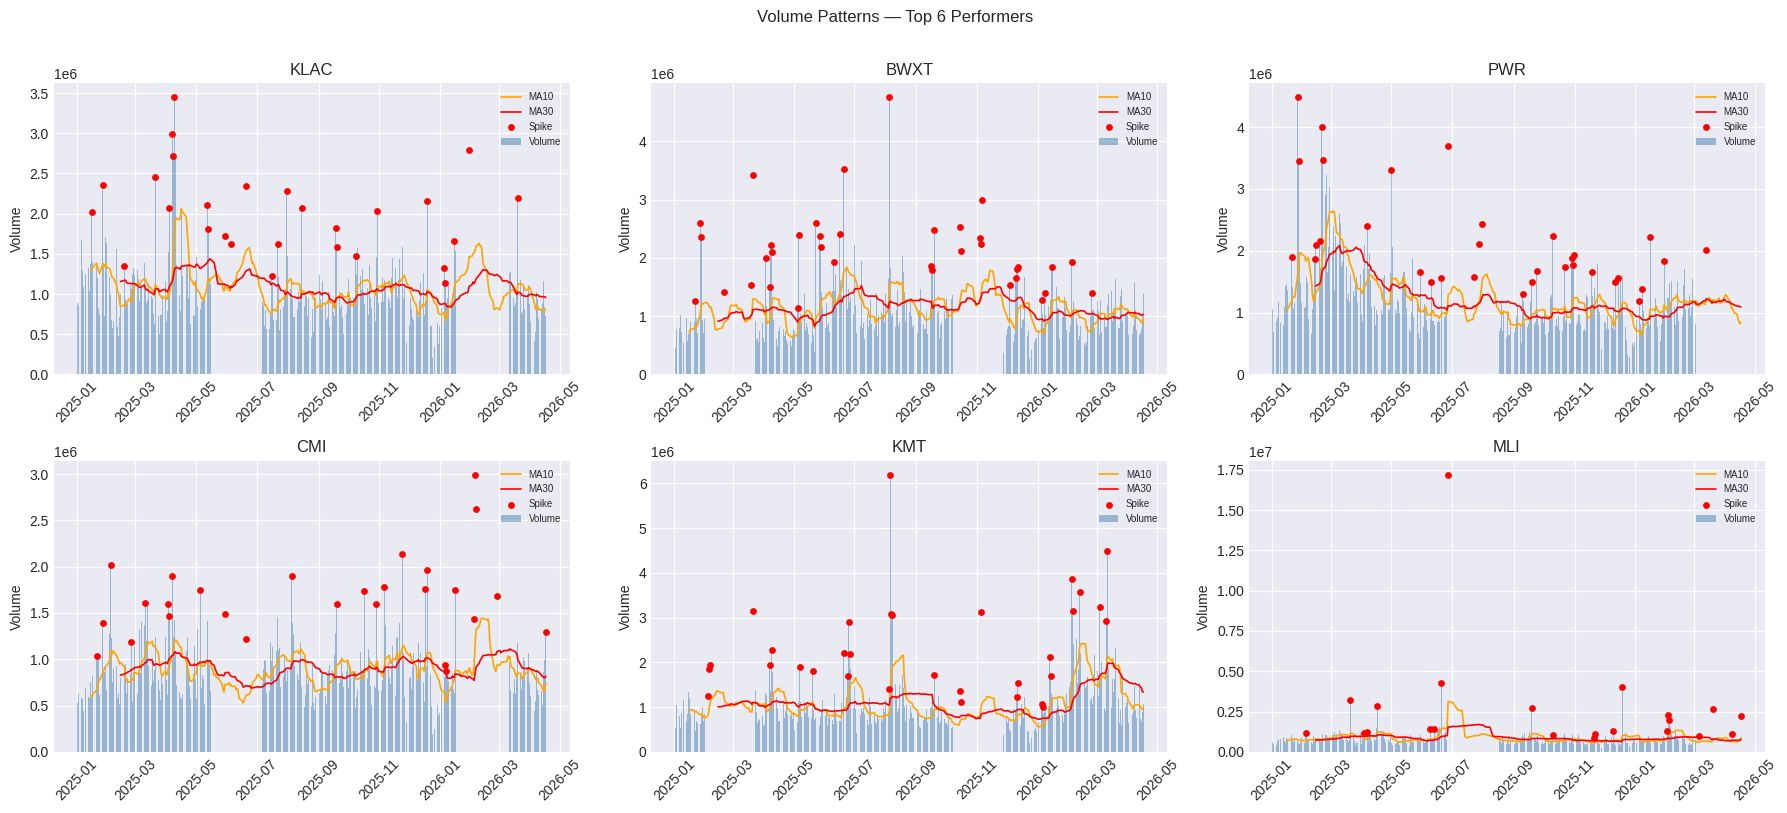

In [6]:
vol_rows = []
for symbol, df in stock_data.items():
    df['Vol_MA10'] = df['Volume'].rolling(10).mean()
    df['Vol_MA30'] = df['Volume'].rolling(30).mean()
    df['Vol_Spike'] = df['Volume'] > df['Vol_MA10'] * 1.5

    spike_days = int(df['Vol_Spike'].sum())
    avg_spike = df.loc[df['Vol_Spike'], 'Volume'].mean()
    avg_normal = df.loc[~df['Vol_Spike'], 'Volume'].mean()
    vol_rows.append({
        'Symbol': symbol,
        'Spike_Days': spike_days,
        'Spike_%': round(spike_days / len(df) * 100, 1),
        'Avg_Spike_Vol': round(avg_spike),
        'Avg_Normal_Vol': round(avg_normal),
        'Spike_Ratio': round(avg_spike / avg_normal, 2) if avg_normal > 0 else np.nan,
    })

vol_df = pd.DataFrame(vol_rows).set_index('Symbol').sort_values('Spike_Days', ascending=False)
n_display = min(15, len(vol_df))
print(f"=== Volume Spike Summary (top {n_display} by spike days) ===")
display(vol_df.head(n_display))

ncols = 3
nrows = -(-len(top_vol) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()
for i, sym in enumerate(top_vol):
    df = stock_data[sym]
    ax = axes[i]
    ax.bar(df.index, df['Volume'], color='steelblue', alpha=0.5, label='Volume')
    ax.plot(df.index, df['Vol_MA10'], color='orange', linewidth=1.2, label='MA10')
    ax.plot(df.index, df['Vol_MA30'], color='red', linewidth=1.2, label='MA30')
    spike_dates = df[df['Vol_Spike']].index
    ax.scatter(spike_dates, df.loc[spike_dates, 'Volume'], color='red', s=15, zorder=5, label='Spike')
    ax.set_title(f'{sym}')
    ax.set_ylabel('Volume')
    ax.legend(fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45)
for ax in axes[len(top_vol):]:
    ax.set_visible(False)

plt.suptitle(f'Volume Patterns — Top {len(top_vol)} Performers', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'volume_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 2: Technical Analysis
### 2.1 Price Trends — SMA & EMA

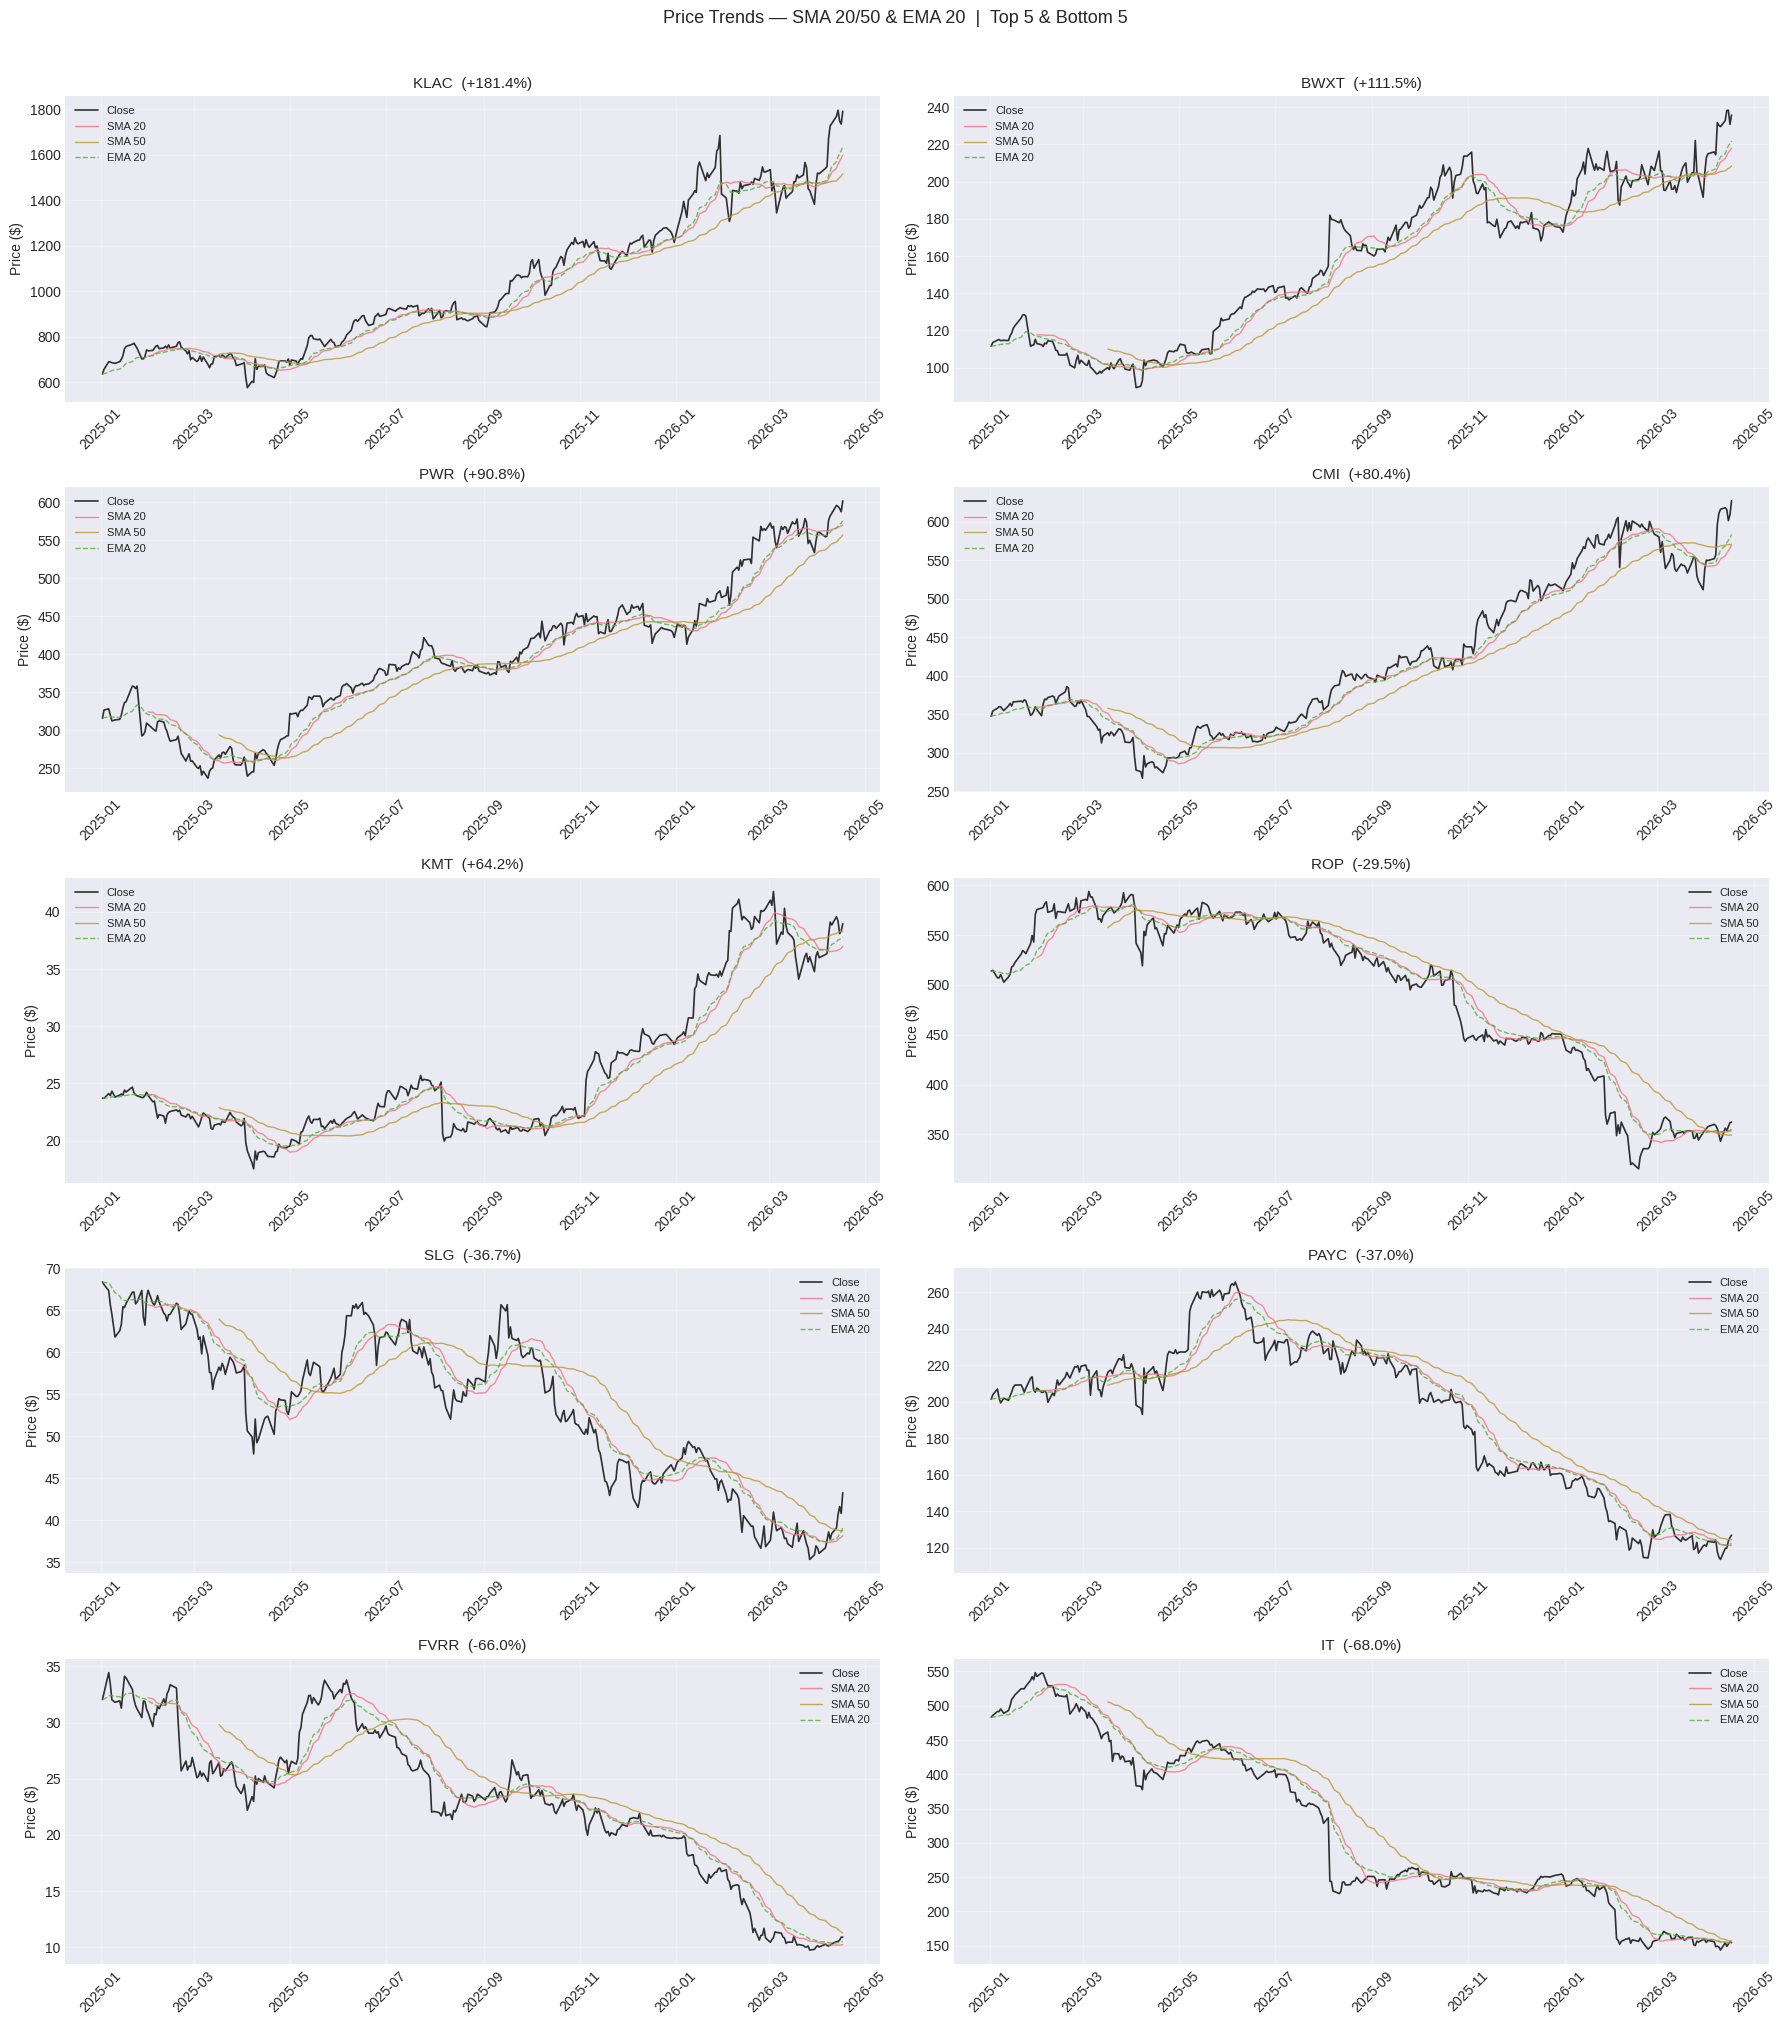

In [7]:
ncols = 2
nrows = -(-len(selected) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 4 * nrows))
axes = axes.flatten()

for i, sym in enumerate(selected):
    df = stock_data[sym]
    ax = axes[i]
    ret = performance_df.loc[sym, 'Total_Return_%']

    ax.plot(df.index, df['Close'], label='Close', linewidth=1.2, color='black', alpha=0.8)
    ax.plot(df.index, df['Close'].rolling(20).mean(), label='SMA 20', linewidth=1, alpha=0.8)
    ax.plot(df.index, df['Close'].rolling(50).mean(), label='SMA 50', linewidth=1, alpha=0.8)
    ax.plot(df.index, df['Close'].ewm(span=20, adjust=False).mean(),
            label='EMA 20', linewidth=1, linestyle='--', alpha=0.8)

    ax.set_title(f'{sym}  ({ret:+.1f}%)', fontsize=11)
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45)

for ax in axes[len(selected):]:
    ax.set_visible(False)

plt.suptitle(f'Price Trends — SMA 20/50 & EMA 20  |  Top {N_SHOWCASE} & Bottom {N_SHOWCASE}',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'price_trends_sma_ema.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Support & Resistance Levels

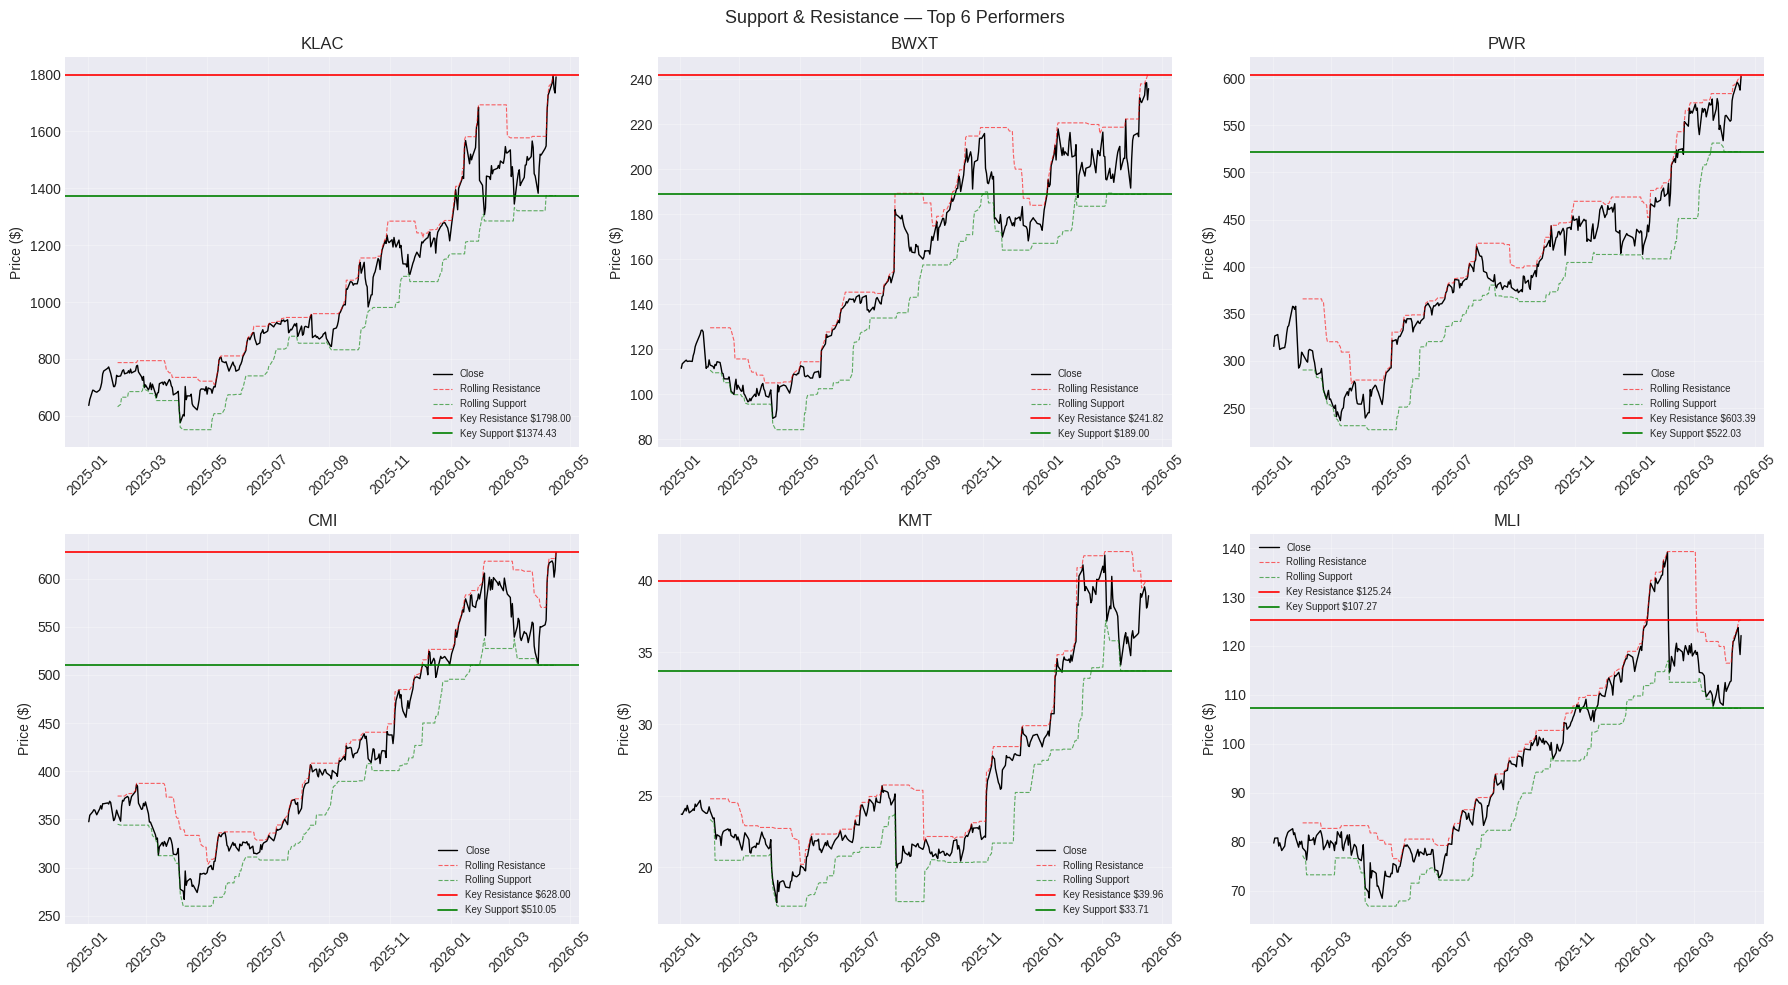

In [8]:
def support_resistance(df, window=20):
    resistance = df['High'].rolling(window).max()
    support = df['Low'].rolling(window).min()
    return resistance, support, df['High'].tail(window).max(), df['Low'].tail(window).min()

ncols = 3
nrows = -(-len(top_vol) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, sym in enumerate(top_vol):
    df = stock_data[sym]
    ax = axes[i]
    resistance, support, r_level, s_level = support_resistance(df)

    ax.plot(df.index, df['Close'], color='black', linewidth=1, label='Close')
    ax.plot(df.index, resistance, color='red', linewidth=0.8, linestyle='--', alpha=0.6, label='Rolling Resistance')
    ax.plot(df.index, support, color='green', linewidth=0.8, linestyle='--', alpha=0.6, label='Rolling Support')
    ax.axhline(y=r_level, color='red', linewidth=1.2, label=f'Key Resistance ${r_level:.2f}')
    ax.axhline(y=s_level, color='green', linewidth=1.2, label=f'Key Support ${s_level:.2f}')
    ax.set_title(sym)
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45)

for ax in axes[len(top_vol):]:
    ax.set_visible(False)

plt.suptitle(f'Support & Resistance — Top {len(top_vol)} Performers', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'support_resistance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.3 MACD — Moving Average Convergence Divergence

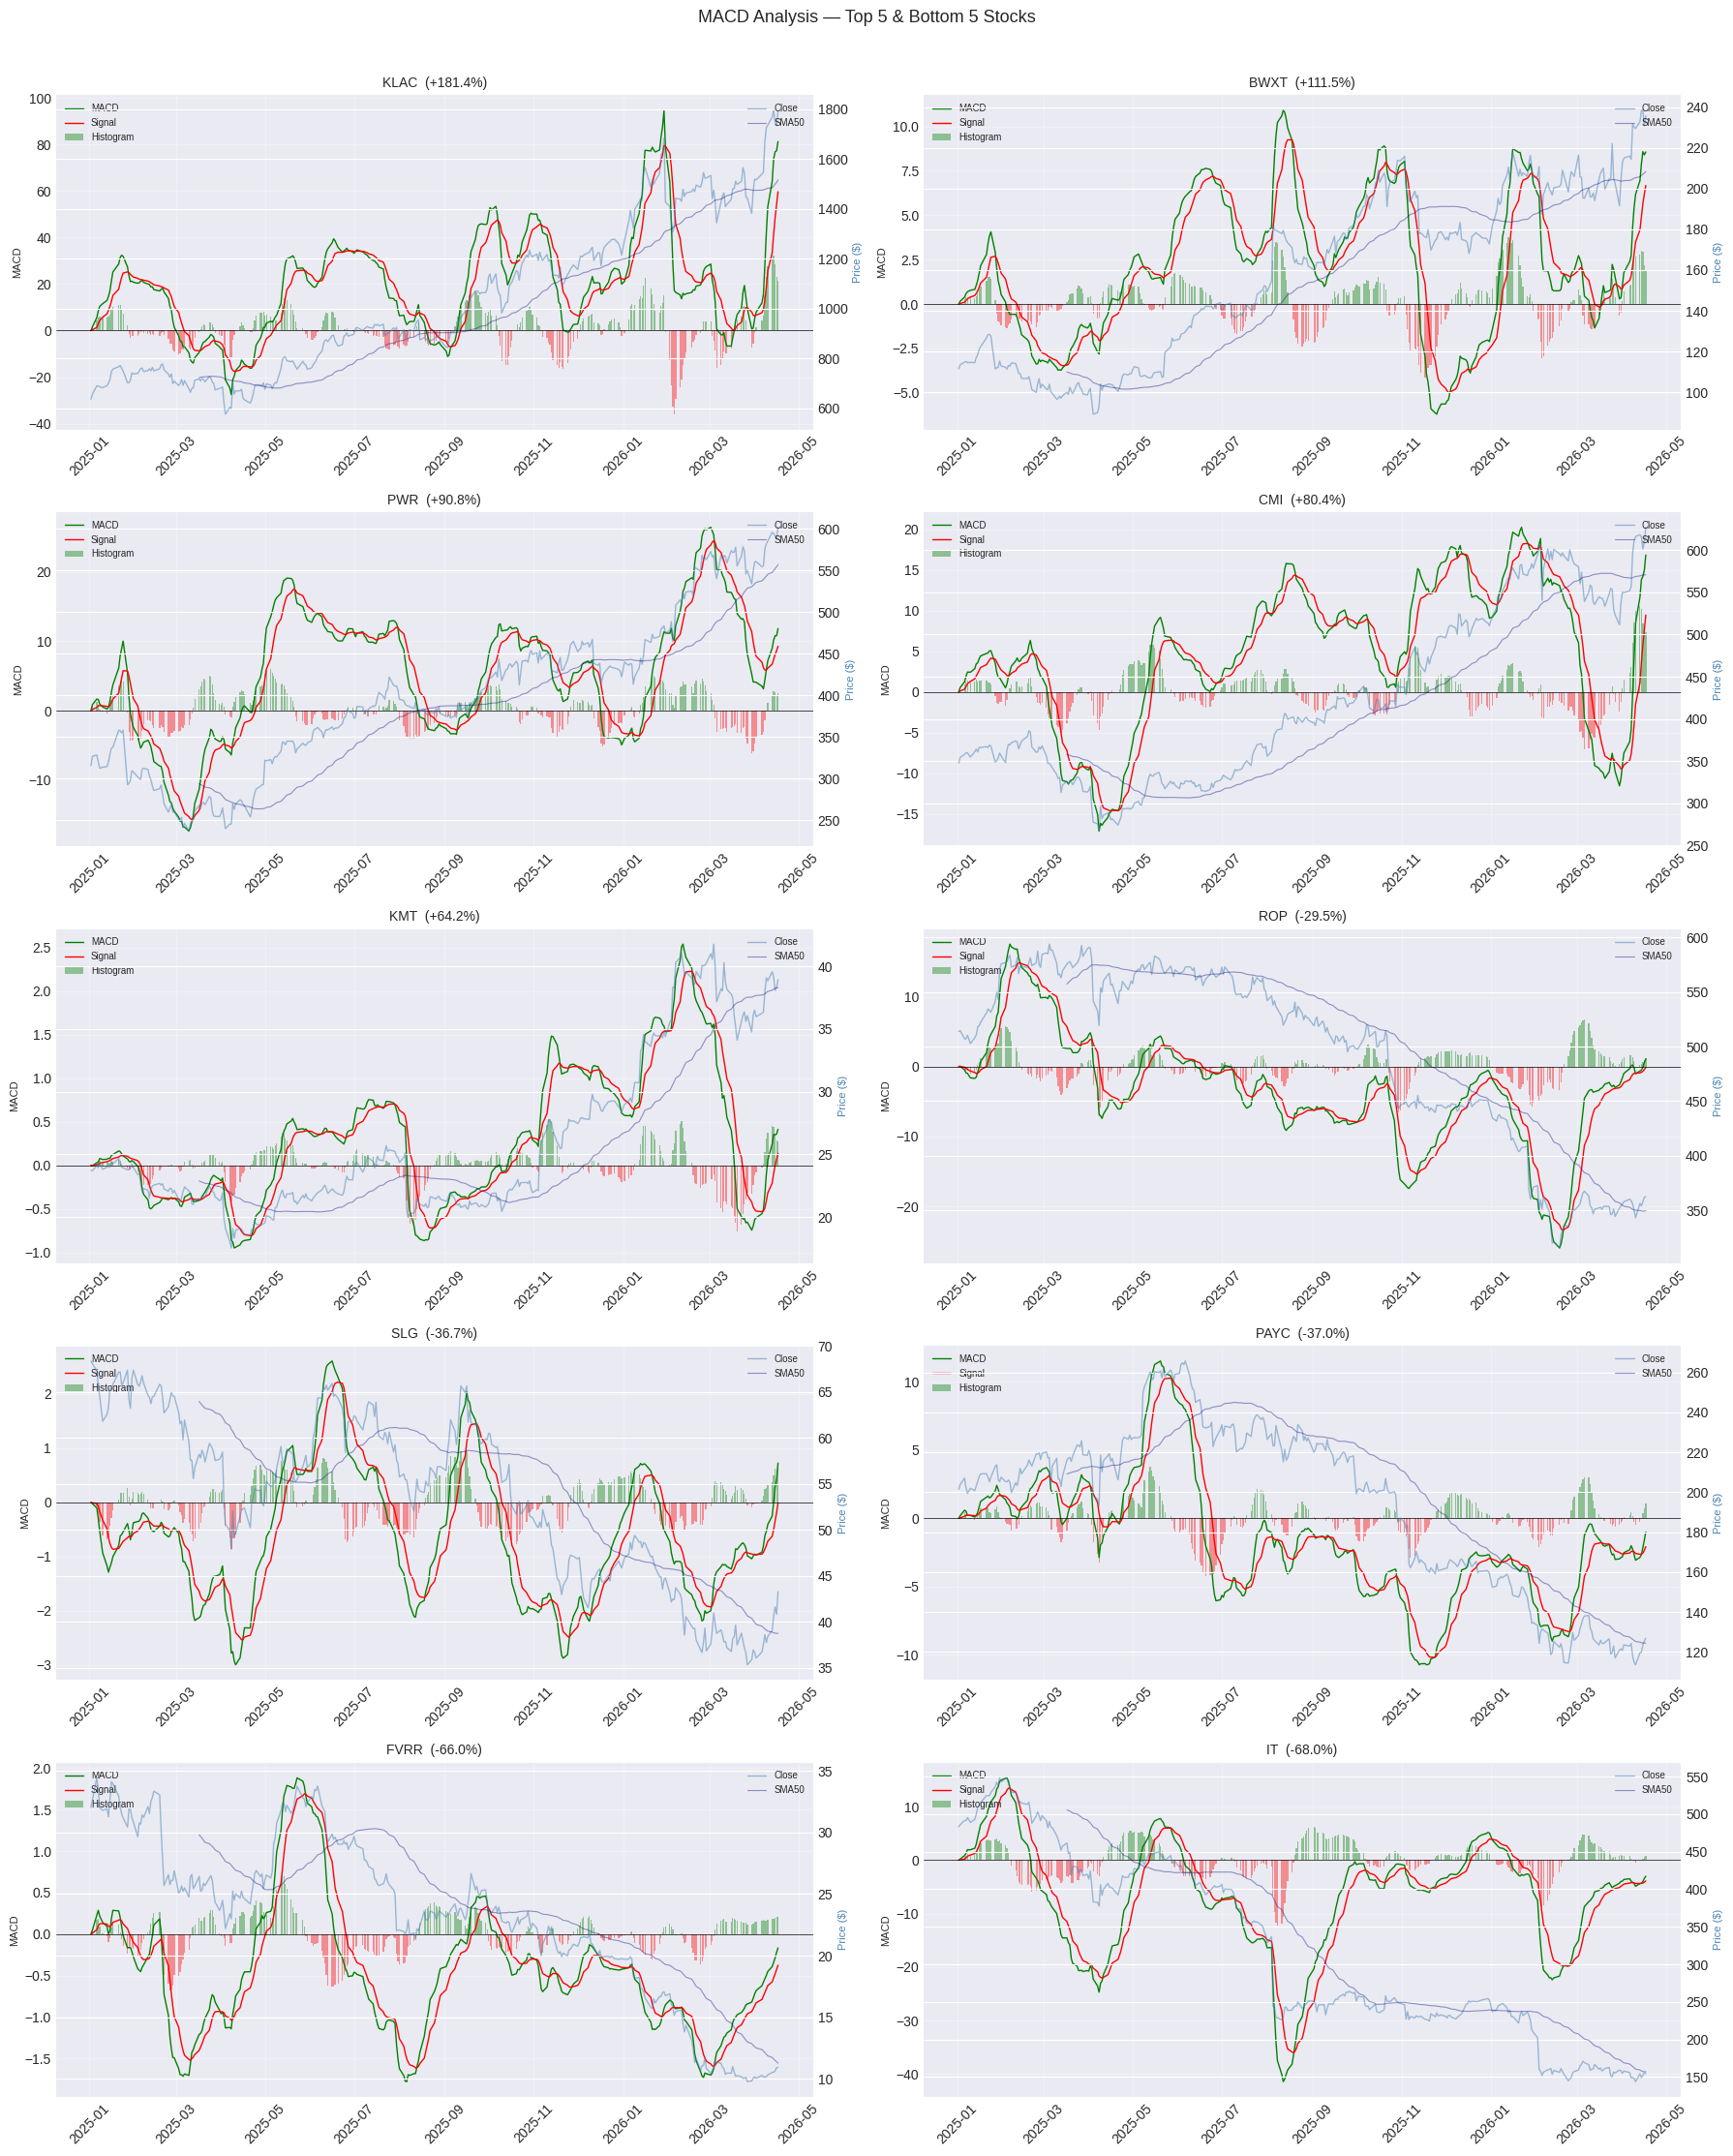

In [9]:
def calculate_macd(df, fast=12, slow=26, signal=9):
    exp1 = df['Close'].ewm(span=fast, adjust=False).mean()
    exp2 = df['Close'].ewm(span=slow, adjust=False).mean()
    macd_line = exp1 - exp2
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for i, sym in enumerate(selected):
    df = stock_data[sym]
    macd_line, signal_line, histogram = calculate_macd(df)

    ax_macd = axes[i]
    ax_price = ax_macd.twinx()

    # Price + SMA50
    ax_price.plot(df.index, df['Close'], color='steelblue', alpha=0.5, linewidth=1, label='Close')
    ax_price.plot(df.index, df['Close'].rolling(50).mean(), color='navy', alpha=0.4, linewidth=0.8, label='SMA50')
    ax_price.set_ylabel('Price ($)', color='steelblue', fontsize=8)

    # MACD
    bar_colors = ['green' if v >= 0 else 'red' for v in histogram]
    ax_macd.bar(histogram.index, histogram, color=bar_colors, alpha=0.4, label='Histogram')
    ax_macd.plot(macd_line.index, macd_line, color='green', linewidth=1, label='MACD')
    ax_macd.plot(signal_line.index, signal_line, color='red', linewidth=1, label='Signal')
    ax_macd.axhline(y=0, color='black', linewidth=0.5)

    total_ret = performance_df.loc[sym, 'Total_Return_%']
    ax_macd.set_title(f'{sym}  ({total_ret:+.1f}%)', fontsize=10)
    ax_macd.set_ylabel('MACD', fontsize=8)
    ax_macd.legend(loc='upper left', fontsize=7)
    ax_price.legend(loc='upper right', fontsize=7)
    ax_macd.grid(True, alpha=0.3)
    plt.setp(ax_macd.get_xticklabels(), rotation=45)

plt.suptitle('MACD Analysis — Top 5 & Bottom 5 Stocks', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'macd_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 3: Market Analysis
### 3.1 Correlation Analysis

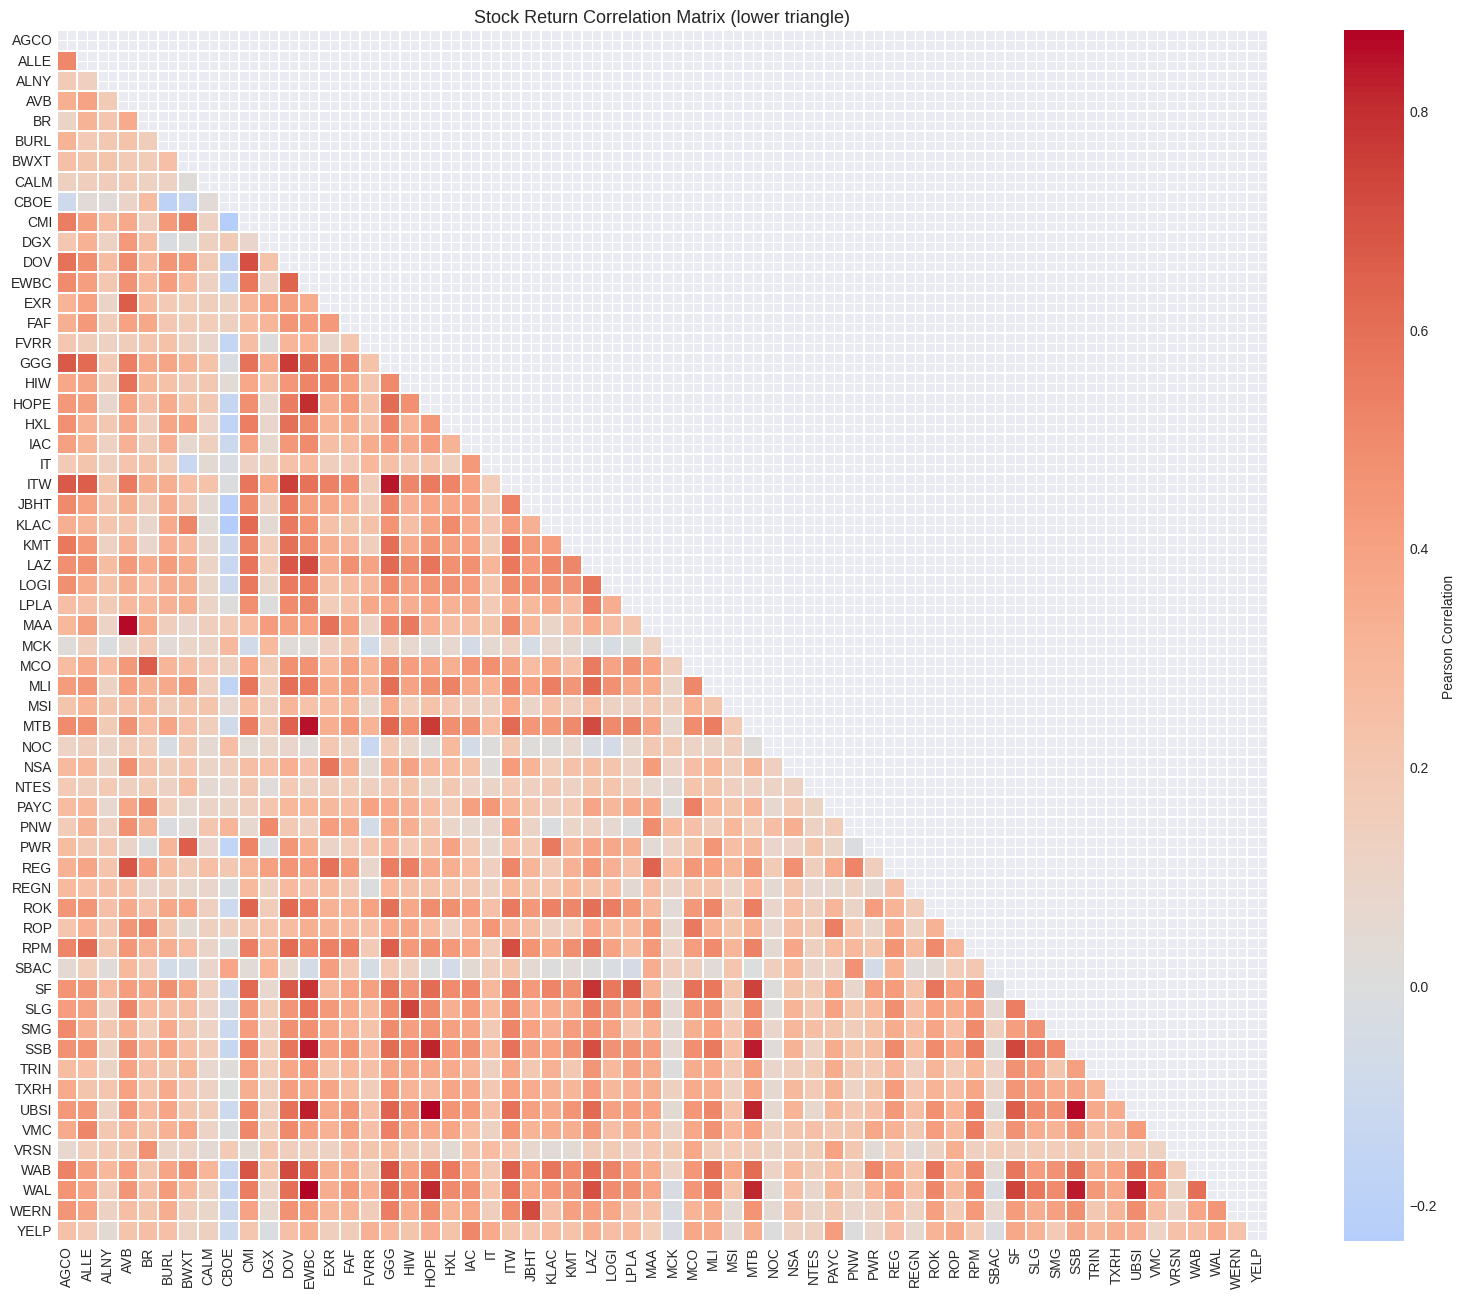

High correlation pairs (|r| > 0.7): 33


,Stock_A,Stock_B,Correlation
11,EWBC,WAL,0.873
16,HOPE,UBSI,0.872
0,AVB,MAA,0.863
30,SSB,UBSI,0.859
7,EWBC,MTB,0.848
12,GGG,ITW,0.842
31,SSB,WAL,0.838
9,EWBC,SSB,0.837
25,MTB,SSB,0.832
32,UBSI,WAL,0.823


In [10]:
returns_df = pd.DataFrame({sym: df['Daily_Return'] for sym, df in stock_data.items()})
corr_matrix = returns_df.corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, square=True,
            linewidths=0.3, cbar_kws={'label': 'Pearson Correlation'}, annot=False)
plt.title('Stock Return Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# High correlation pairs
high_corr = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.7:
            high_corr.append({'Stock_A': cols[i], 'Stock_B': cols[j], 'Correlation': round(c, 3)})

high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
print(f"High correlation pairs (|r| > 0.7): {len(high_corr_df)}")
display(high_corr_df.head(20))

### 3.2 Sector Performance Analysis

,Count,Avg_Return_%,Median_Return_%,Avg_Volatility,Best,Worst
Sector,,,,,,
Industrial,19,37.40,39.37,0.3157,BWXT,WERN
Healthcare,4,29.92,30.87,0.3308,MCK,REGN
Technology,10,11.82,3.80,0.3438,KLAC,IT
Financial,15,8.50,6.64,0.3119,CBOE,BR
Consumer,6,-8.90,-4.20,0.3802,IAC,FVRR
Real Estate,6,-14.24,-17.99,0.2555,REG,SLG


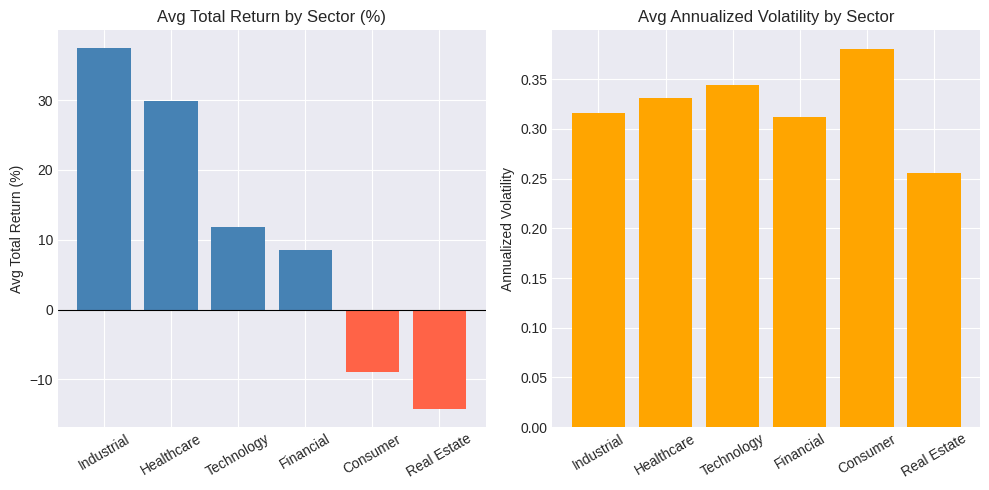

In [11]:
import json

sector_map_path = os.path.join(OUTPUT_PATH, 'sector_map.json')
if os.path.exists(sector_map_path):
    with open(sector_map_path) as f:
        SECTOR_MAPPING = json.load(f)
else:
    SECTOR_MAPPING = {}
    print("⚠ sector_map.json not found — all stocks will be classified as 'Other'")

sector_stats = {}
for sym in performance_df.index:
    sector = SECTOR_MAPPING.get(sym, 'Other')
    if sector not in sector_stats:
        sector_stats[sector] = {'returns': [], 'vols': [], 'symbols': []}
    sector_stats[sector]['returns'].append(performance_df.loc[sym, 'Total_Return_%'])
    sector_stats[sector]['vols'].append(performance_df.loc[sym, 'Ann_Volatility'])
    sector_stats[sector]['symbols'].append(sym)

sector_summary = []
for sector, data in sector_stats.items():
    sector_summary.append({
        'Sector': sector,
        'Count': len(data['symbols']),
        'Avg_Return_%': round(np.mean(data['returns']), 2),
        'Median_Return_%': round(np.median(data['returns']), 2),
        'Avg_Volatility': round(np.mean(data['vols']), 4),
        'Best': max(data['symbols'], key=lambda s: performance_df.loc[s, 'Total_Return_%']),
        'Worst': min(data['symbols'], key=lambda s: performance_df.loc[s, 'Total_Return_%']),
    })

sector_df = pd.DataFrame(sector_summary).set_index('Sector').sort_values('Avg_Return_%', ascending=False)
display(sector_df)

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(sector_df) * 1.5), 5))
colors = ['steelblue' if r > 0 else 'tomato' for r in sector_df['Avg_Return_%']]
axes[0].bar(sector_df.index, sector_df['Avg_Return_%'], color=colors)
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Avg Total Return by Sector (%)')
axes[0].set_ylabel('Avg Total Return (%)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(sector_df.index, sector_df['Avg_Volatility'], color='orange')
axes[1].set_title('Avg Annualized Volatility by Sector')
axes[1].set_ylabel('Annualized Volatility')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'sector_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Pairs Trading Opportunities

In [12]:
pairs_opps = []
for _, row in high_corr_df.head(20).iterrows():
    s1, s2 = row['Stock_A'], row['Stock_B']
    r1 = returns_df[s1].dropna()
    r2 = returns_df[s2].dropna()
    spread = r1 - r2
    spread_mean = spread.mean()
    spread_std = spread.std()
    recent_mean = spread.tail(20).mean()
    z_score = (recent_mean - spread_mean) / spread_std if spread_std > 0 else 0
    pairs_opps.append({
        'Pair': f'{s1}-{s2}',
        'Correlation': row['Correlation'],
        'Z_Score': round(z_score, 3),
        'Spread_Mean': round(spread_mean, 6),
        'Spread_Std': round(spread_std, 6),
    })

pairs_df = pd.DataFrame(pairs_opps).sort_values('Z_Score', key=abs, ascending=False)
print("=== Top Pairs Trading Opportunities (by spread deviation) ===")
display(pairs_df.head(15))

=== Top Pairs Trading Opportunities (by spread deviation) ===


,Pair,Correlation,Z_Score,Spread_Mean,Spread_Std
0,EWBC-WAL,0.873,-0.246,0.000667,0.013561
1,HOPE-UBSI,0.872,0.199,-0.000367,0.009207
13,MTB-WAL,0.815,-0.194,0.000351,0.016801
16,LAZ-SF,0.783,0.188,-0.000401,0.017461
2,AVB-MAA,0.863,0.183,-0.000133,0.007079
9,UBSI-WAL,0.823,-0.180,0.000446,0.016629
17,EWBC-SF,0.774,-0.178,0.000217,0.013925
6,SSB-WAL,0.838,-0.174,0.000022,0.015425
18,HOPE-MTB,0.769,0.173,-0.000273,0.012132
15,EWBC-HOPE,0.797,-0.173,0.000589,0.012651


---
## Phase 4: Advanced Analysis — Pattern Recognition
### 4.1 Head & Shoulders / Double Top & Bottom Detection

In [13]:
def detect_head_and_shoulders(df, window=20):
    signals = []
    for i in range(window * 2, len(df) - window):
        left_sh = df['High'].iloc[i - window*2:i - window].max()
        head = df['High'].iloc[i - window:i].max()
        right_sh = df['High'].iloc[i:i + window].max()
        if (left_sh > head * 1.01 and right_sh > head * 1.01 and
                head < left_sh * 0.98 and head < right_sh * 0.98):
            signals.append({'date': df.index[i], 'pattern': 'H&S Top', 'price': head})
        ls_low = df['Low'].iloc[i - window*2:i - window].min()
        head_low = df['Low'].iloc[i - window:i].min()
        rs_low = df['Low'].iloc[i:i + window].min()
        if (ls_low < head_low * 0.99 and rs_low < head_low * 0.99 and
                head_low > ls_low * 1.02 and head_low > rs_low * 1.02):
            signals.append({'date': df.index[i], 'pattern': 'H&S Bottom', 'price': head_low})
    return signals

def detect_double_top_bottom(df, window=20):
    signals = []
    for i in range(window * 2, len(df) - window):
        p1 = df['High'].iloc[i - window*2:i - window].max()
        valley = df['Low'].iloc[i - window:i].min()
        p2 = df['High'].iloc[i:i + window].max()
        if (abs(p1 - p2) / p1 < 0.02 and valley < min(p1, p2) * 0.97 and p1 > df['High'].mean()):
            signals.append({'date': df.index[i], 'pattern': 'Double Top', 'price': max(p1, p2)})
        v1 = df['Low'].iloc[i - window*2:i - window].min()
        peak = df['High'].iloc[i - window:i].max()
        v2 = df['Low'].iloc[i:i + window].min()
        if (abs(v1 - v2) / v1 < 0.02 and peak > max(v1, v2) * 1.03 and v1 < df['Low'].mean()):
            signals.append({'date': df.index[i], 'pattern': 'Double Bottom', 'price': min(v1, v2)})
    return signals

# Run pattern detection on all stocks
pattern_counts = []
for sym, df in stock_data.items():
    hs = detect_head_and_shoulders(df)
    db = detect_double_top_bottom(df)
    pattern_counts.append({
        'Symbol': sym,
        'H&S_Patterns': len(hs),
        'Double_Top_Bottom': len(db),
        'Total_Patterns': len(hs) + len(db)
    })

pat_df = pd.DataFrame(pattern_counts).set_index('Symbol').sort_values('Total_Patterns', ascending=False)
print("=== Pattern Detection Summary (all stocks) ===")
display(pat_df[pat_df['Total_Patterns'] > 0].head(20))
print(f"\nTotal H&S patterns detected: {pat_df['H&S_Patterns'].sum()}")
print(f"Total Double Top/Bottom detected: {pat_df['Double_Top_Bottom'].sum()}")

=== Pattern Detection Summary (all stocks) ===


,H&S_Patterns,Double_Top_Bottom,Total_Patterns
Symbol,,,
PNW,48,215,263
REG,15,197,212
GGG,53,155,208
IAC,122,65,187
TRIN,68,114,182
DGX,54,127,181
FAF,71,101,172
BURL,104,55,159
BR,35,122,157



Total H&S patterns detected: 3351
Total Double Top/Bottom detected: 3273


### 4.2 Breakout Analysis

=== Breakout Analysis (top 15 by net breakouts) ===


,Breakouts_Up,Breakdowns,Net
Symbol,,,
AGCO,0,0,0
ALLE,0,0,0
ALNY,0,0,0
AVB,0,0,0
BR,0,0,0
BURL,0,0,0
BWXT,0,0,0
CALM,0,0,0
CBOE,0,0,0


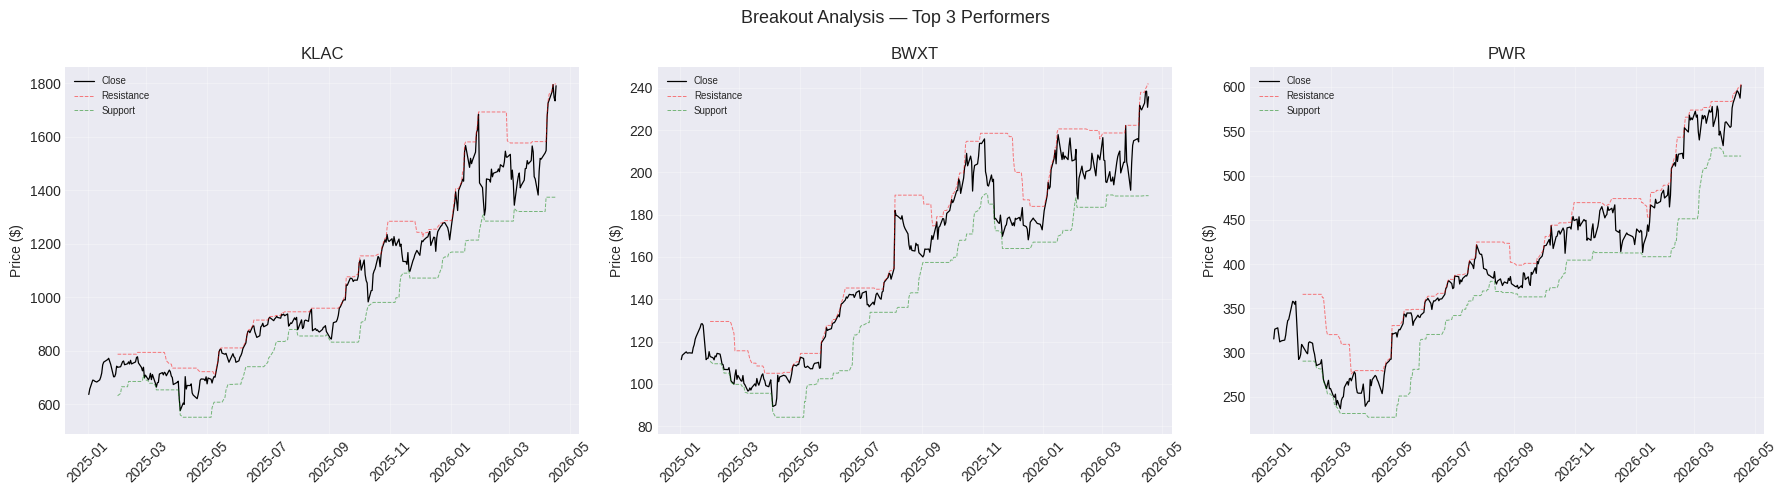

In [14]:
def detect_breakouts(df, window=20):
    resistance = df['High'].rolling(window).max()
    support = df['Low'].rolling(window).min()
    breakouts_up, breakdowns = [], []
    for i in range(1, len(df)):
        price, prev = df['Close'].iloc[i], df['Close'].iloc[i - 1]
        res, sup = resistance.iloc[i], support.iloc[i]
        if price > res and prev <= res:
            breakouts_up.append({'date': df.index[i], 'price': price, 'level': res})
        elif price < sup and prev >= sup:
            breakdowns.append({'date': df.index[i], 'price': price, 'level': sup})
    return breakouts_up, breakdowns, resistance, support

# Single pass — compute and cache results for every stock
bo_cache = {}
bo_rows = []
for sym, df in stock_data.items():
    bu, bd, res, sup = detect_breakouts(df)
    bo_cache[sym] = (bu, bd, res, sup)
    bo_rows.append({'Symbol': sym, 'Breakouts_Up': len(bu), 'Breakdowns': len(bd), 'Net': len(bu) - len(bd)})

bo_df = pd.DataFrame(bo_rows).set_index('Symbol').sort_values('Net', ascending=False)
n_display = min(15, len(bo_df))
print(f"=== Breakout Analysis (top {n_display} by net breakouts) ===")
display(bo_df.head(n_display))

# Plot — use cached results, no recomputation
fig, axes = plt.subplots(1, len(top_bo), figsize=(6 * len(top_bo), 5))
if len(top_bo) == 1:
    axes = [axes]
for i, sym in enumerate(top_bo):
    bu, bd, resistance, support = bo_cache[sym]
    df = stock_data[sym]
    ax = axes[i]
    ax.plot(df.index, df['Close'], color='black', linewidth=0.9, label='Close')
    ax.plot(df.index, resistance, color='red', linewidth=0.7, linestyle='--', alpha=0.5, label='Resistance')
    ax.plot(df.index, support, color='green', linewidth=0.7, linestyle='--', alpha=0.5, label='Support')
    if bu:
        ax.scatter([b['date'] for b in bu], [b['price'] for b in bu],
                   color='green', marker='^', s=50, zorder=5, label=f'Breakout Up ({len(bu)})')
    if bd:
        ax.scatter([b['date'] for b in bd], [b['price'] for b in bd],
                   color='red', marker='v', s=50, zorder=5, label=f'Breakdown ({len(bd)})')
    ax.set_title(f'{sym}')
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.suptitle(f'Breakout Analysis — Top {len(top_bo)} Performers', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'breakout_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis Summary

### Phase 1 — EDA
- Dataset loaded from `DATASET_PATH`; stock count, date range, and quality reported dynamically
- Performance ranked by total return; top/bottom N driven by `N_SHOWCASE`
- Volume spikes defined as > 1.5× 10-day MA; spike counts vary per stock

### Phase 2 — Technical Analysis
- SMA 20/50 and EMA 20 plotted for `selected` stocks (top & bottom N)
- MACD (12/26/9) with color-coded histogram applied to the same `selected` set
- Support/resistance: rolling 20-day High/Low window + last-window key level, for `top_vol` stocks

### Phase 3 — Market Analysis
- Correlation matrix across all loaded stocks; high-corr pairs (|r| > 0.7) tabulated
- Sector mapping loaded from `sector_map.json` (add new symbols there — unknown symbols → "Other")
- Pairs trading: z-score of recent 20-day spread vs historical mean, ranked by deviation

### Phase 4 — Pattern Recognition
- H&S and Double Top/Bottom scanned across all stocks
- Breakout/breakdown computed in a single pass and cached; plot reuses cache for `top_bo` stocks

### Output Files Generated
| File | Description |
|---|---|
| `performance_overview.png` | Return bar chart + risk-return scatter (Sharpe color) |
| `volume_patterns.png` | Volume + MA10/MA30 + spike markers |
| `price_trends_sma_ema.png` | Price + SMA 20/50 + EMA 20 |
| `support_resistance.png` | Rolling S/R + key level lines |
| `macd_analysis.png` | MACD histogram + price overlay |
| `correlation_matrix.png` | Lower-triangle Pearson heatmap |
| `sector_performance.png` | Avg return & volatility by sector |
| `breakout_analysis.png` | Breakout/breakdown signals |